# [ML] v1 vs v2 세그먼트 품질 비교 — 2026-07-04

Issue #18: #4에서 만든 v1(LLM이 persona taxonomy를 직접 생성)과 #15~#17에서 만든 v2(KMeans 클러스터링 + LLM naming) 방식의 세그먼트 품질을 정량 지표로 비교한다.

Full 데이터 단일 트랙 기준(Issue #23 반영) — Full vs US 비교는 하지 않는다.

In [1]:
# 1. 표준 라이브러리
import json
from collections import Counter
from pathlib import Path

# 2. 서드파티
import numpy as np
import pandas as pd

# 3. 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

np.random.seed(42)

# 한국어 폰트 설정 (macOS 기준, 없으면 기본 폰트로 폴백)
_KOREAN_FONT_CANDIDATES = ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"]
_available = {f.name for f in fm.fontManager.ttflist}
for _font in _KOREAN_FONT_CANDIDATES:
    if _font in _available:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

sns.set_palette("colorblind")
sns.set_style("whitegrid")

ROOT_DIR = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
INTERIM_DIR = ROOT_DIR / "data" / "interim"
print("ROOT_DIR:", ROOT_DIR)

ROOT_DIR: /Users/leeyonghyek/Desktop/tobigs_conference/무제


## 1. 데이터 로드 & 기본 검사

- v1: `data/interim/funnel_persona_gen/user_persona_labels_v1.json` — 유저 406명(전체 16,268명 중 2.5% 샘플) 라벨링 결과
- v2: `data/processed/customer_segments_all_customers.csv` — 전체 20,000명 segment_id 배정 결과
- v2 naming: `data/processed/segment_personas_v2.json` — #17 채택본

In [2]:
with open(INTERIM_DIR / "funnel_persona_gen" / "user_persona_labels_v1.json", encoding="utf-8") as f:
    v1_data = json.load(f)

v2_customer_segments = pd.read_csv(PROCESSED_DIR / "customer_segments_all_customers.csv")

with open(PROCESSED_DIR / "segment_personas_v2.json", encoding="utf-8") as f:
    v2_personas = json.load(f)

print(f"v1 샘플 크기: {v1_data['sample_size']:,}명 / 전체 {v1_data['total_users']:,}명")
print(f"v2 고객 수: {len(v2_customer_segments):,}명, segment 수: {v2_customer_segments['segment_id'].nunique()}개")

v1_status_counts = Counter(label["status"] for label in v1_data["labels"])
print("v1 라벨링 상태:", dict(v1_status_counts))

assert v2_customer_segments["customer_id"].duplicated().sum() == 0, "customer_id 중복 존재"
assert v2_customer_segments["segment_id"].isna().sum() == 0, "segment_id 결측 존재"
print("v2 무결성 검증 통과: customer_id 중복 없음, segment_id 결측 없음")

v1 샘플 크기: 406명 / 전체 16,268명
v2 고객 수: 20,000명, segment 수: 6개
v1 라벨링 상태: {'ok': 371, 'unparseable': 22, 'unrepresentable': 13}
v2 무결성 검증 통과: customer_id 중복 없음, segment_id 결측 없음


## 2. 정량 지표 비교

coverage, entropy, top-k concentration, segment size balance를 계산한다.

**주의**: v1은 유저당 최대 5개 persona를 붙이는 다중 라벨(multi-label) 방식이고, v2는 KMeans로 1명당 segment_id 1개를 부여하는 단일 라벨(single-label) 방식이다. entropy를 직접 비교할 때 이 구조적 차이를 감안해야 한다.

In [3]:
def shannon_entropy(ratios: pd.Series) -> float:
    """비율 분포의 Shannon entropy(bit 단위)를 계산한다."""
    nonzero = ratios[ratios > 0]
    return float(-(nonzero * np.log2(nonzero)).sum())


def normalized_entropy(ratios: pd.Series) -> float:
    """entropy를 log2(그룹 수)로 정규화한다."""
    n = len(ratios)
    if n <= 1:
        return np.nan
    return shannon_entropy(ratios) / np.log2(n)


def top_k_concentration(ratios: pd.Series, k: int) -> float:
    """상위 k개 그룹의 비율 합을 계산한다."""
    return float(ratios.sort_values(ascending=False).head(k).sum())

In [4]:
# v1 지표: ok 상태인 유저의 persona 배정만 사용
v1_ok_labels = [label for label in v1_data["labels"] if label["status"] == "ok"]
v1_persona_picks = [p for label in v1_ok_labels for p in label["personas"]]
v1_persona_counts = Counter(v1_persona_picks)
v1_total_picks = sum(v1_persona_counts.values())
v1_ratios = pd.Series({p: c / v1_total_picks for p, c in v1_persona_counts.items()}).sort_values(ascending=False)

v1_metrics = {
    "method": "v1 (LLM 직접 생성)",
    "n_groups": len(v1_ratios),
    "sample_size": v1_data["sample_size"],
    "total_population": v1_data["total_users"],
    "coverage_of_sample": round(len(v1_ok_labels) / v1_data["sample_size"], 4),
    "coverage_of_total_population": round(len(v1_ok_labels) / v1_data["total_users"], 4),
    "entropy": round(shannon_entropy(v1_ratios), 4),
    "normalized_entropy": round(normalized_entropy(v1_ratios), 4),
    "top1_concentration": round(top_k_concentration(v1_ratios, 1), 4),
    "top2_concentration": round(top_k_concentration(v1_ratios, 2), 4),
    "min_group_ratio": round(float(v1_ratios.min()), 4),
    "max_group_ratio": round(float(v1_ratios.max()), 4),
    "avg_labels_per_user": round(v1_total_picks / len(v1_ok_labels), 4),
}

# v2 지표: 고객당 segment_id 1개
v2_counts = v2_customer_segments["segment_id"].value_counts()
v2_ratios = (v2_counts / len(v2_customer_segments)).sort_values(ascending=False)

v2_metrics = {
    "method": "v2 (KMeans + LLM naming)",
    "n_groups": len(v2_ratios),
    "sample_size": len(v2_customer_segments),
    "total_population": len(v2_customer_segments),
    "coverage_of_sample": 1.0,
    "coverage_of_total_population": 1.0,
    "entropy": round(shannon_entropy(v2_ratios), 4),
    "normalized_entropy": round(normalized_entropy(v2_ratios), 4),
    "top1_concentration": round(top_k_concentration(v2_ratios, 1), 4),
    "top2_concentration": round(top_k_concentration(v2_ratios, 2), 4),
    "min_group_ratio": round(float(v2_ratios.min()), 4),
    "max_group_ratio": round(float(v2_ratios.max()), 4),
    "avg_labels_per_user": 1.0,
}

comparison = pd.DataFrame([v1_metrics, v2_metrics]).set_index("method")
comparison

,n_groups,sample_size,total_population,coverage_of_sample,coverage_of_total_population,entropy,normalized_entropy,top1_concentration,top2_concentration,min_group_ratio,max_group_ratio,avg_labels_per_user
method,,,,,,,,,,,,
v1 (LLM 직접 생성),20,406,16268,0.9138,0.0228,4.0054,0.9268,0.1412,0.2290,0.0030,0.1412,2.7305
v2 (KMeans + LLM naming),6,20000,20000,1.0000,1.0000,2.5112,0.9715,0.2319,0.4569,0.0879,0.2319,1.0000


## 3. 분포 시각화

/var/folders/51/kq2vl_6x475blp8p60f51j980000gn/T/ipykernel_66238/1554078995.py:17: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/51/kq2vl_6x475blp8p60f51j980000gn/T/ipykernel_66238/1554078995.py:17: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/51/kq2vl_6x475blp8p60f51j980000gn/T/ipykernel_66238/1554078995.py:17: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/51/kq2vl_6x475blp8p60f51j980000gn/T/ipykernel_66238/1554078995.py:17: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/51/kq2vl_6x475blp8p60f51j980000gn/T/ipykernel_66238/1554078995.py:17: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/51/kq2vl_6x475blp8p60f51j980000gn/T/ipykernel_66238/1554078995.py:17: U

/Users/leeyonghyek/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leeyonghyek/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leeyonghyek/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leeyonghyek/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/leeyonghyek/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGU

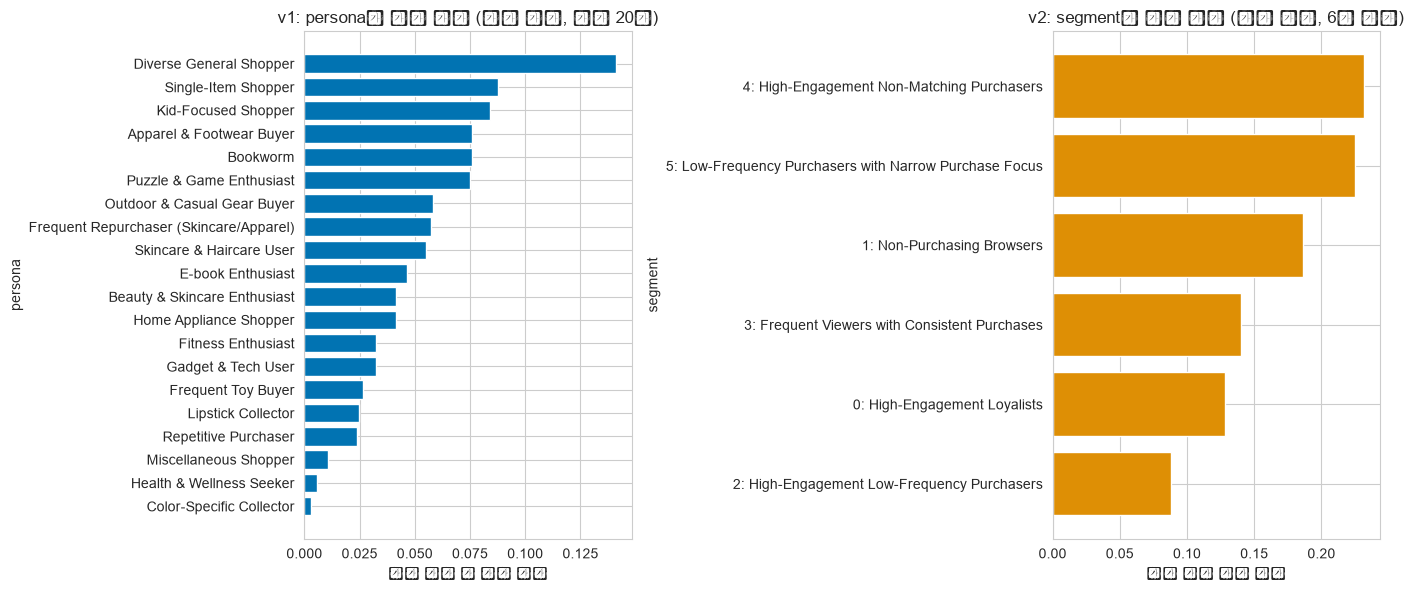

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

v1_top = v1_ratios.head(20)
axes[0].barh(v1_top.index[::-1], v1_top.values[::-1], color=sns.color_palette("colorblind")[0])
axes[0].set_title("v1: persona별 배정 비율 (다중 라벨, 상위 20개)")
axes[0].set_xlabel("전체 배정 수 대비 비율")
axes[0].set_ylabel("persona")

v2_labeled = v2_ratios.rename(
    {p["segment_id"]: f"{p['segment_id']}: {p['segment_name']}" for p in v2_personas}
)
axes[1].barh(v2_labeled.index[::-1], v2_labeled.values[::-1], color=sns.color_palette("colorblind")[1])
axes[1].set_title("v2: segment별 고객 비율 (단일 라벨, 6개 전체)")
axes[1].set_xlabel("전체 고객 대비 비율")
axes[1].set_ylabel("segment")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "v1_vs_v2_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. broad/artifact persona 비교

v1 품질 플래그는 `reports/[EDA]_전체_vs_US_페르소나_생성_비교_2026-06-30.md` §5에서 Full 20개 persona를 수동 검토해 집계한 값이다. v2는 채택된 6개 segment_name을 같은 기준으로 검토했다.

| 플래그 | 의미 | v1 (20개 중) | v2 (6개 중) |
|---|---|---:|---:|
| broad_or_misc | 너무 포괄적인 이름(`Miscellaneous`, `General`, `Mixed` 등) | 2 | 0 |
| color_artifact | synthetic 색상/상품명에 끌려간 이름 | 2 | 0 |
| repeat_or_single | 카테고리 연결성이 약한 이름 | 3 | 0 |
| dense_group | 같은 카테고리 내 중복/유사 persona | 15 | 0* |

**`color_artifact`, `repeat_or_single`이 v2에서 구조적으로 0인 이유**: v2는 LLM에 raw 상품명을 애초에 보여주지 않으므로 이 실패 유형 자체가 발생할 수 없다. "v2가 더 잘해서"가 아니라 "이 문제가 생길 수 없는 설계"라는 점을 리포트에서 구분해야 한다.

**`dense_group`에 `*`를 붙인 이유**: v2 segment_name 6개 중 3개(`High-Engagement Loyalists`, `High-Engagement Low-Frequency Purchasers`, `High-Engagement Non-Matching Purchasers`)가 "High-Engagement" 접두어를 공유한다. 표면적으로는 v1의 dense_group과 비슷해 보이지만, 실제 `segment_summary_all_customers.csv` 수치를 보면 이 세 세그먼트는 페이지뷰가 높다는 공통점만 있을 뿐 구매전환율·카테고리 일치율이 뚜렷이 달라 진짜 중복은 아니다. 다만 naming 스타일이 반복되는 점은 리뷰 포인트로 남겨야 한다(아래 코드로 실제 수치 차이를 확인).

In [6]:
high_engagement_ids = [
    p["segment_id"] for p in v2_personas if "High-Engagement" in p["segment_name"]
]
segment_summary = pd.read_csv(PROCESSED_DIR / "segment_summary_all_customers.csv")
check_cols = [
    "segment_id",
    "purchaser_ratio",
    "avg_order_count",
    "view_purchase_category_match_rate",
    "avg_page_view_count",
]
segment_summary[segment_summary["segment_id"].isin(high_engagement_ids)][check_cols]

,segment_id,purchaser_ratio,avg_order_count,view_purchase_category_match_rate,avg_page_view_count
0,0,1.000000,3.087092,1.000000,35.851089
2,2,0.996587,1.653584,0.463595,14.699659
4,4,1.000000,2.906014,0.000000,35.754042


## 5. 핵심 해석 및 한계

**핵심 발견**

- coverage: v2(100%)가 v1(전체 모집단 대비 2.28%)보다 압도적으로 높다. v1은 비용 문제로 2.5%만 샘플링했기 때문.
- 그룹 크기 균형: v1은 최소~최대 persona 비율이 47배 차이 나는 반면, v2는 2.6배로 훨씬 균형적이다.
- 정규화 entropy: v2(0.972)가 v1(0.927)보다 높아, 자기 그룹 수 대비로도 v2가 더 고르게 분포한다.
- broad/artifact persona: v1은 20개 중 다수(특히 dense_group 15개)가 품질 문제를 가졌지만, v2는 채택된 6개에서 구조적/실질적으로 문제가 발견되지 않았다.

**한계 및 주의점**

- v1과 v2는 단일 라벨 vs 다중 라벨 구조가 달라 entropy·top-k concentration을 완전히 동일한 의미로 비교할 수는 없다.
- v1의 coverage가 낮은 것은 방법론 자체의 한계라기보다 샘플링 비율(2.5%) 설정에 기인한 부분이 크다 — 전량 라벨링했다면 달라질 수 있다.
- v2의 KMeans silhouette score가 낮다는 점(`reports/[ML]_segment_cluster_k_비교_2026-07-02.md`)은 여전히 유효한 한계이며, segment 경계를 명확한 자연 군집으로 과잉 해석하면 안 된다.
- 이번 비교는 Full 데이터 단일 트랙 기준이다(Issue #23 반영, Full vs US 비교는 범위에서 제외됨).
- `dense_group` 관련해서는 v2도 naming 스타일(공유 접두어)에 대한 검토가 필요하며 완전히 무결하다고 보기는 어렵다.